In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Subset
import pickle
import wandb

from decoding_model import *
from data_utils import *
from tqdm import tqdm

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # if using CUDA

In [2]:
# Loading in data
load_wfs = np.load('/sdf/home/c/carsmith/sdf_data/flash_detection_data/flash_files/delay_200ks/2_8.npy', allow_pickle=True)
dataset = WaveformDataset(load_wfs.item())

g = torch.Generator()
g.manual_seed(seed)

# Splitting data
val_ratio = 0.75
total_size = len(dataset)
val_size = int(total_size * val_ratio)
train_size = total_size - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=g)

batch_size = 25

In [3]:
def decoding_collate_fn(batch):
    '''
    Each item in batch is a tuple: (waveform, arrival_times, hit_times, photon_bins, photon_list)
    batch_size = 25

    We need to construct: 
        Normalized waveforms for training - Normalized signal amplitude, maybe also width? not sure 

        Targets for evaluating loss:
        targets[b] = {
            "start_time": tensor of shape [num_gt_b],  # normalized 0..1
            "duration": tensor of shape [num_gt_b],    # normalized 0..1
            "photons": tensor of shape [num_gt_b]      # scalar
        }
    '''
    waveforms, arrival_times, hit_times, photon_bins, photon_list = zip(*batch) # all of these are tuples of length 25
    batch_size = len(waveforms)
    window_len = waveforms[0].shape[0]

    # Stack & normalize waveforms
    waveforms = torch.stack(waveforms, dim=0) # [B, L]
    waveforms = (waveforms - waveforms.mean(dim=1, keepdim=True)) / (waveforms.std(dim=1, keepdim=True) + 1e-8)
    waveforms = waveforms.unsqueeze(1)

    # Build targets
    targets = []
    for b in range(batch_size):
        hit_times_b = torch.tensor(hit_times[b], dtype=torch.float32) # start times, length 8, pads with 0's
        hit_times_b = hit_times_b[hit_times_b > 0]
        
        photon_counts = torch.tensor(photon_list[b], dtype=torch.float32) # scalar photons per pulse
        photon_counts = photon_counts[photon_counts > 0]
        # photon_counts = F.pad(photon_counts, (0, 8 - photon_counts.shape[0]))  # pad with zeros on the right

        num_real_pulses = hit_times_b.shape[0]
        
        durations = torch.full((num_real_pulses,), 800.0, dtype=torch.float32) # all pulses have same width... not really learning anything
        # durations = F.pad(durations, (0, 8 - durations.shape[0]))
        
        # Normalize to [0,1] relative to waveform length
        start_norm = hit_times_b / window_len
        duration_norm = durations / window_len

        target = {
            "start_time": start_norm,
            "duration": duration_norm,
            "photons": photon_counts
        }
        targets.append(target)
    
    return waveforms, targets

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=g,
    collate_fn=decoding_collate_fn,
    num_workers=0,
    pin_memory=False,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=decoding_collate_fn,
    num_workers=0,
    pin_memory=False,
    drop_last=False
)

total photons in waveform:  2039.0


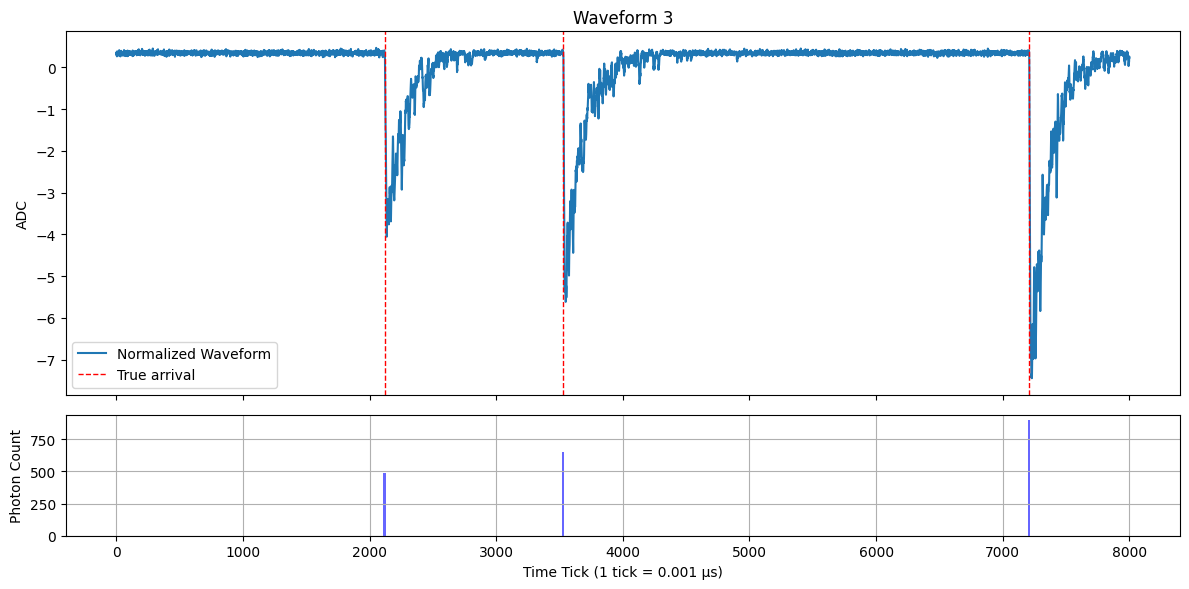

In [4]:
waveforms, targets = next(iter(train_loader))

waveform_id = 3
wf = waveforms[waveform_id]  # [1, L]
ticks = torch.arange(wf.shape[-1])  # [0, 1, ..., L-1]
wf = wf.squeeze(0)  # [L]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# --- Top panel: waveform ---
ax1.plot(ticks, wf, alpha=1, label='Normalized Waveform')

# Mark true hits
for j, t in enumerate(targets[waveform_id]['start_time']):
    if t >= 0:
        ax1.axvline(
            x=t * wf.shape[0], 
            color='r', 
            linestyle='--', 
            linewidth=1, 
            label='True arrival' if j == 0 else ""
        )

ax1.set_title(f"Waveform {waveform_id}")
ax1.set_ylabel("ADC")
ax1.legend()

# --- Bottom panel: photon counts ---
photon_counts = targets[waveform_id]['photons'].cpu().numpy()
print("total photons in waveform: ", photon_counts.sum())
ax2.bar(targets[waveform_id]['start_time']*wf.shape[0], photon_counts, width=20.0, color='b', alpha=0.6)
ax2.set_ylabel("Photon Count")
ax2.set_xlabel("Time Tick (1 tick = 0.001 μs)")
ax2.grid()
plt.tight_layout()
plt.show()

### Try to run training

In [5]:
def _compute_grad_norm(parameters, norm_type=2.0):
    """Compute gradient norm for given parameters."""
    if isinstance(parameters, torch.Tensor):
        parameters = [parameters]
    
    grads = [p.grad for p in parameters if p.grad is not None]
    if len(grads) == 0:
        return torch.tensor(0.0)
    
    if norm_type == float('inf'):
        total_norm = max(g.abs().max() for g in grads)
    else:
        total_norm = torch.norm(
            torch.stack([torch.norm(g, norm_type) for g in grads]), 
            norm_type
        )
    
    return total_norm

In [6]:
epochs = 50
batch_size = 25

logger = wandb.init(
    project="decoding_test",
    name="overfit_on_500_nozeros",
    config={
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": 1e-4,
    }
)

device = 'cuda'

model = DecodingModel()
model.to(device)
model.train()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")
wandb.watch(model, log="all", log_freq=100)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

train_progress = tqdm(train_loader, desc=f"Epoch {1}/{epochs}", leave=False, position=0, disable=False)
val_progress = tqdm(val_loader, desc='Validating', leave=False, position=0)

for epoch in range(epochs):
    train_loss = 0.0
    signal_loss = 0.0
    reg_loss = 0.0
    conf_loss = 0.0
    
    for i, (waveforms, targets) in enumerate(train_progress):
        model.train()
        waveforms = waveforms.to(device)
    
        signal_output, reg_output, confidence_output = model(waveforms)
    
        loss, loss_signal, loss_photon, confidence_loss = set_based_loss(signal_output, reg_output, confidence_output, targets)
        train_loss += loss
        signal_loss += loss_signal
        conf_loss += confidence_loss
        reg_loss += loss_photon
    
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_progress.set_postfix({"train_loss": train_loss/(i+1)})
        
    logger.log({
        "epoch": epoch,
        "train_loss": train_loss / len(train_loader),
        "signal_loss": signal_loss / len(train_loader),
        "reg_loss": reg_loss / len(train_loader),
        "conf_loss": conf_loss / len(train_loader),
        # "grad_norm": _compute_grad_norm(model.parameters(), norm_type=2)
    })

    # if epoch % 1 == 0:
    #     torch.cuda.empty_cache()
    #     val_loss = 0.0
    #     val_signal_loss = 0.0
    #     val_reg_loss = 0.0
    #     val_conf_loss = 0.0
        
    #     model.eval()
    #     for i, (waveforms, targets) in enumerate(val_progress):
    #         waveforms = waveforms.to(device)
    #         signal_output, reg_output, confidence_output = model(waveforms)
        
    #         loss, loss_signal, loss_photon, confidence_loss = set_based_loss(signal_output, reg_output, confidence_output, targets)
    #         val_loss += loss
    #         val_signal_loss += loss_signal
    #         val_reg_loss += loss_photon
    #         val_conf_loss += confidence_loss
            
    #     logger.log({
    #         "epoch": epoch,
    #         "val_loss": val_loss / len(val_loader),
    #         "val_signal_loss": val_signal_loss / len(val_loader),
    #         "val_reg_loss": val_reg_loss / len(val_loader),
    #         "val_conf_loss": val_conf_loss / len(val_loader),
    #     })
    
wandb.finish()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: carsmith (carsmith-stanford-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Total number of parameters: 7322628


Validating:   0%|          | 0/6000 [00:00<?, ?it/s]/sdf/home/c/carsmith/flash_reconstruction/flash_detection/notebooks/../decoding_model.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matched_idx = torch.tensor(row_ind, device=device)
Epoch 1/50:   5%|▍         | 99/2000 [00:15<04:05,  7.75it/s, train_loss=tensor(0.6555, device='cuda:0', grad_fn=<DivBackward0>)]/sdf/home/c/carsmith/flash_reconstruction/flash_detection/notebooks/../decoding_model.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  matched_idx = torch.tensor(row_ind, device=device)
                                                                                                                                   

KeyboardInterrupt: 

### Look at at an example

In [ ]:
# load a checkpoint
# device = 'cuda'

# model = DecodingModel()
# model.to(device)
# model.eval()
# total_params = sum(p.numel() for p in model.parameters())
# print(f"Total number of parameters: {total_params}")

# checkpoint = torch.load(f"/sdf/home/c/carsmith/sdf_data/flash_detection_data/decoder_path.pth", weights_only=True)
# model.load_state_dict(checkpoint['model_state_dict'])

In [7]:
# Inference on an example
val_waveforms, val_targets = next(iter(val_loader))
val_waveforms = val_waveforms.to(device)

model.eval()
signal_output, reg_output, _ = model(val_waveforms)
print(signal_output[6] * 8000)

tensor([[4251.2480, 3998.8008],
        [4440.8535, 3998.7131],
        [3899.7454, 3998.7112],
        [4039.8589, 3998.4133],
        [4771.6436, 3998.5537],
        [3795.9336, 4000.0039],
        [4134.8574, 3999.8770],
        [3480.9741, 3998.4177]], device='cuda:0', grad_fn=<MulBackward0>)


total photons in waveform:  1373.0


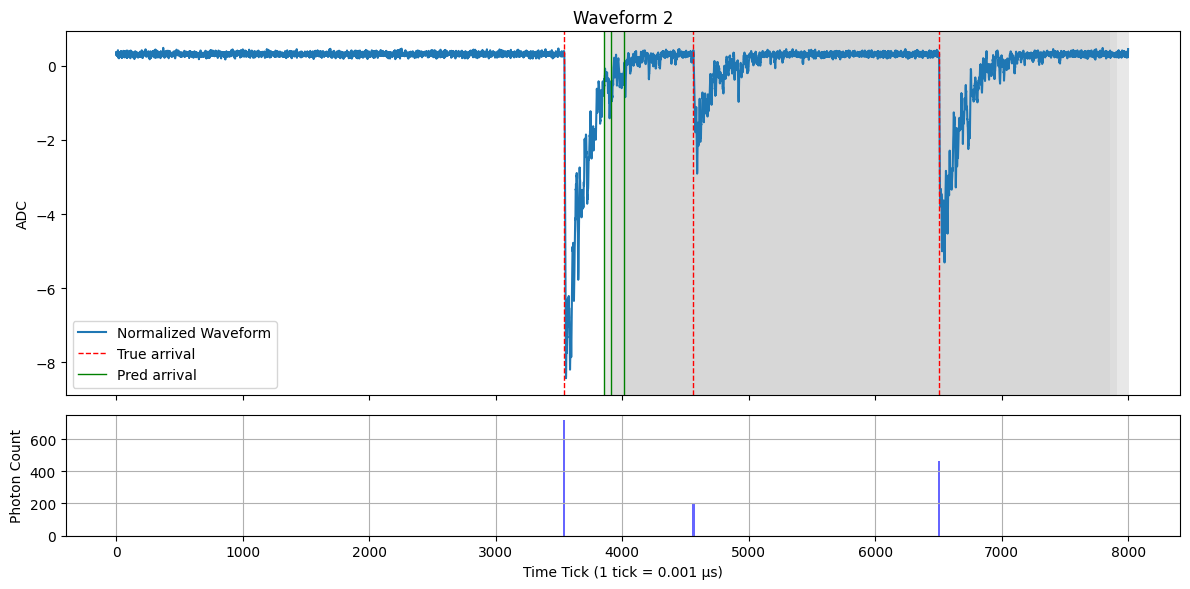

In [12]:
waveform_id = 2
target = val_targets[waveform_id]

row_ind, col_ind = hungarian_match(signal_output[waveform_id], reg_output[waveform_id], target)
matched_pred_signal = signal_output[waveform_id][row_ind].detach().cpu().numpy()
matched_pred_photon = reg_output[waveform_id][row_ind].detach().cpu().numpy()

matched_gt_signal = torch.stack([target['start_time'], target['duration']], dim=1)[col_ind].cpu().numpy()
matched_gt_photon = target['photons'][col_ind].unsqueeze(1).cpu().numpy()

wf = val_waveforms[waveform_id].cpu()  # [1, L]
ticks = torch.arange(wf.shape[-1])  # [0, 1, ..., L-1]
wf = wf.squeeze(0)  # [L]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# --- Top panel: waveform ---
ax1.plot(ticks, wf, alpha=1, label='Normalized Waveform')

# Mark true hits
for j, t in enumerate(matched_gt_signal):
    if t[0] >= 0:
        ax1.axvline(
            x=t[0] * wf.shape[0], 
            color='r', 
            linestyle='--', 
            linewidth=1, 
            label='True arrival' if j == 0 else ""
        )
        
# Mark predicted start times
for j, t in enumerate(matched_pred_signal):
    if t[0] >= 0:
        ax1.axvline(
            x=t[0] * wf.shape[0],
            color='g',
            linestyle='-',
            linewidth=1,
            label='Pred arrival' if j == 0 else ""
        )
        ax1.axvspan(t[0]*wf.shape[0], (t[0] + t[1])*wf.shape[0], facecolor='lightgray', alpha=0.5)

ax1.set_title(f"Waveform {waveform_id}")
ax1.set_ylabel("ADC")
ax1.legend()

# --- Bottom panel: photon counts ---
photon_counts = val_targets[waveform_id]['photons'].cpu().numpy()
print("total photons in waveform: ", photon_counts.sum())
ax2.bar(val_targets[waveform_id]['start_time']*wf.shape[0], photon_counts, width=20.0, color='b', alpha=0.6)
ax2.set_ylabel("Photon Count")
ax2.set_xlabel("Time Tick (1 tick = 0.001 μs)")
ax2.grid()
plt.tight_layout()
plt.show()

In [11]:
print(matched_gt_photon[col_ind])
print(matched_pred_photon[col_ind])
rmse = np.sqrt(np.mean((matched_gt_photon - matched_pred_photon) ** 2))

print(rmse)

[[656.]
 [776.]
 [306.]
 [456.]
 [728.]
 [ 86.]
 [755.]
 [196.]]
[[595.47845 ]
 [956.2319  ]
 [284.6221  ]
 [471.42844 ]
 [688.9323  ]
 [116.830414]
 [853.67676 ]
 [124.696014]]
82.26451


In [10]:
print(matched_gt_signal)
print(matched_pred_signal)
print(np.sqrt(np.mean((matched_gt_signal*8000 - matched_pred_signal*8000) ** 2)))

[[0.79225  0.1     ]
 [0.306625 0.1     ]
 [0.788125 0.1     ]
 [0.522875 0.1     ]
 [0.311    0.1     ]
 [0.0125   0.1     ]
 [0.89075  0.1     ]
 [0.034375 0.1     ]]
[[0.55230075 0.49984133]
 [0.6527527  0.49983788]
 [0.36212492 0.4998558 ]
 [0.50874096 0.49980673]
 [0.5958965  0.49981827]
 [0.41955328 0.50003296]
 [0.5561612  0.49994308]
 [0.39473328 0.49979243]]
2916.7551


### Evaluation

In [ ]:
def single_sample_accuracy(masked_gt_signal, masked_pred_signal):
    # absolute error for start_time and duration
    diff = torch.abs(masked_gt_signal - masked_pred_signal)

    # consider a prediction correct if both start_time and duration are within tol
    correct = (diff <= tol).all(dim=1)

    # accuracy = fraction of correct predictions
    accuracy = correct.float().mean() if correct.numel() > 0 else torch.tensor(0.0)

    return accuracy

def purity():
    pass